In [1]:
import os
import sys
from os import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
import json
import argparse
from scipy.optimize import least_squares
import coord_helper as ch
import extra_functions as ef
import h5py
import skyfield.api as sf
import importlib
from numpy.linalg import inv
import numbers

BDC is using numpy


In [43]:
day = '11_11'
bits = 1
baseline_idx = 1

config_file_name = f'config_{day}.json'
working_directory = '/project/s/sievers/thomasb/mars_data_23'

In [44]:
with open(f"{working_directory}/{bits}bit/{day}/{config_file_name}", "r") as f:
    config = json.load(f)
    dir_parents = []
    coords = []
    # unpack information from the json file
    # Call get_starting_index for all antennas except reference
    for i, (ant, details) in enumerate(config["antennas"].items()):
        if (i == 0) or (i ==baseline_idx):
            coords.append(details['coordinates'])
            dir_parents.append(details["path"])
    global_start_time = config["correlation"]["start_timestamp"]
    end_t = config["correlation"]["end_timestamp"]
    v_acclen = config["correlation"]["vis_acclen"]
    visibility_window = config["correlation"]["visibility_window"]
    T_SPECTRA = config["correlation"]["point_PFB"] / config["correlation"]["sample_rate"]


ref_coords = coords[0]
v_nchunks = int((visibility_window)/(v_acclen* T_SPECTRA))
chanlist = np.arange(1834, 1852, dtype=int)

context = [visibility_window, T_SPECTRA, v_acclen, v_nchunks, ref_coords]
print(global_start_time)

1699680012


In [45]:
filtering = 'auto'

In [46]:
pl = []

if filtering == 'auto':

    with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_autoselected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
        for p in f:
            pulse_info = []
            chan_big_idx = int(f[p].attrs['chan'])
            chan_small_idx = np.where(chanlist == chan_big_idx)[0][0]

            pulse_info.append(p)
            pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
            pulse_info.append([int(f[p].attrs['sat']), chan_big_idx])
            pulse_info.append(f[p].attrs['tle_path'])
            vis = np.angle(f[f'/{p}'])
            angle = np.unwrap(vis[:,chan_small_idx])
            pulse_info.append(np.unwrap(angle - angle[0]))
            pulse_info.append(f[f'/{p}'][:])
            pl.append(pulse_info)

if filtering == 'manual':
    with h5py.File(f'{working_directory}/{bits}bit/{day}/vis_selected_bline_{baseline_idx}_{global_start_time}.h5', 'r') as f:
        for p in f:
            pulse_info = []
            pulse_info.append(p)
            pulse_info.append([f[p].attrs['start_time'], f[p].attrs['end_time'], int(f[p].attrs['global_start_time'])])
            pulse_info.append([int(f[p].attrs['sat']), int(f[p].attrs['chan'])])
            pulse_info.append(f[p].attrs['tle_path'])
            pulse_info.append(np.unwrap(angle))
            pulse_info.append(f[f'/{p}'][:])
            pl.append(pulse_info)


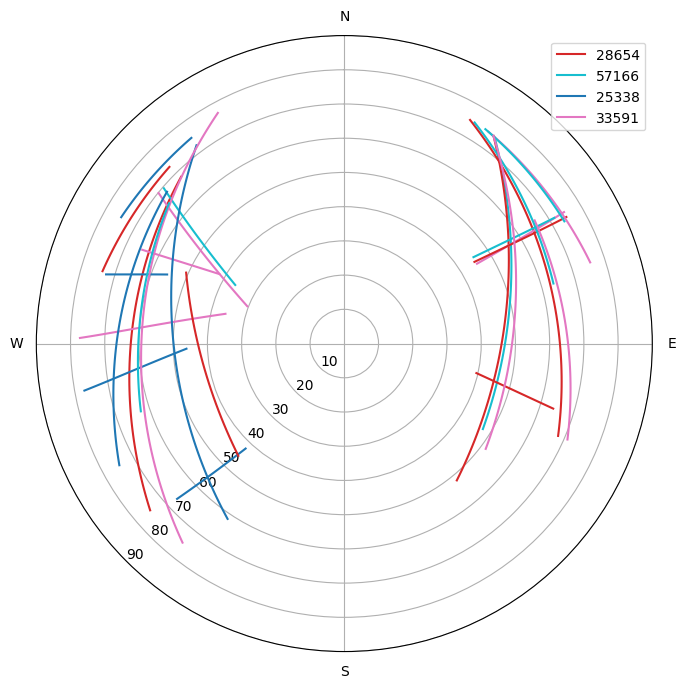

In [47]:
fig = ch.satpass_plotter(pl, coords[1])

In [48]:
importlib.reload(ch)
importlib.reload(ef)

<module 'extra_functions' from '/home/s/sievers/thomasb/albatros_analysis/scripts/orbcomm/fitting/extra_functions.py'>

In [39]:
N = len(pl)
fits = []
window = 4

for i in range(N - window + 1):
    idx = slice(i, i+window)
    pulses = pl[idx]
    fit = ef.solid_irls_verbose(coords[1], 0, ef.pred, pulses, context, iterations = 20)
    fits.append(fit)

time for one delay pred: 0.013310670852661133
time taken pred 0.013567209243774414
time for one delay pred: 0.009577274322509766
time taken pred 0.009679317474365234
time for one delay pred: 0.016540050506591797
time taken pred 0.016638755798339844
time for one delay pred: 0.018568754196166992
time taken pred 0.018670320510864258
time for one delay pred: 0.012072086334228516
time taken pred 0.012165069580078125
time for one delay pred: 0.009413480758666992
time taken pred 0.009503364562988281
time for one delay pred: 0.015944719314575195
time taken pred 0.016039133071899414
time for one delay pred: 0.018489360809326172
time taken pred 0.01858687400817871
time for one delay pred: 0.012068510055541992
time taken pred 0.01215815544128418
time for one delay pred: 0.009378194808959961
time taken pred 0.009463071823120117
time for one delay pred: 0.0159604549407959
time taken pred 0.0160520076751709
time for one delay pred: 0.018076419830322266
time taken pred 0.018192529678344727
time for o

time for one delay pred: 0.01596832275390625
time taken pred 0.01617264747619629
time for one delay pred: 0.018075227737426758
time taken pred 0.01817178726196289
time for one delay pred: 0.0120086669921875
time taken pred 0.012096166610717773
time for one delay pred: 0.009218692779541016
time taken pred 0.009303092956542969
time for one delay pred: 0.01596808433532715
time taken pred 0.01605987548828125
time for one delay pred: 0.018285512924194336
time taken pred 0.018380403518676758
time for one delay pred: 0.011927604675292969
time taken pred 0.012015819549560547
time for one delay pred: 0.009307861328125
time taken pred 0.009392499923706055
time for one delay pred: 0.016038179397583008
time taken pred 0.01612997055053711
time for one delay pred: 0.017978668212890625
time taken pred 0.018072128295898438
time for one delay pred: 0.012015104293823242
time taken pred 0.012101173400878906
time for one delay pred: 0.009260177612304688
time taken pred 0.009345293045043945
time for one de

KeyboardInterrupt: 

In [28]:
print(fits)

[]


In [29]:
tuple_list = []
for i in range(len(fits)):
    tuple_list.append((i, fits[i]))

tuple_list.append(('ALL', result_all))

NameError: name 'result_all' is not defined

In [49]:
fits = ef.solid_irls_verbose(coords[1], 0, ef.pred, pl, context, iterations = 20)

time for one delay pred: 0.02775406837463379
time taken pred 0.028116226196289062
time for one delay pred: 0.031252384185791016
time taken pred 0.03139686584472656
time for one delay pred: 0.027025699615478516
time taken pred 0.027157306671142578
time for one delay pred: 0.014862298965454102
time taken pred 0.014977693557739258
time for one delay pred: 0.03100872039794922
time taken pred 0.03114938735961914
time for one delay pred: 0.019831418991088867
time taken pred 0.01996159553527832
time for one delay pred: 0.014356374740600586
time taken pred 0.014447212219238281
time for one delay pred: 0.010967254638671875
time taken pred 0.01105642318725586
time for one delay pred: 0.00953817367553711
time taken pred 0.009623050689697266
time for one delay pred: 0.014445781707763672
time taken pred 0.014533519744873047
time for one delay pred: 0.012337207794189453
time taken pred 0.012423276901245117
time for one delay pred: 0.0094146728515625
time taken pred 0.009500265121459961
time for one 

In [50]:
for i in range(len(fits)):
    print(fits[i])

[ 79.4171933  -90.75890542 183.36474039]
[ 79.4171885  -90.75890204 183.33622355]
[ 79.41718645 -90.75889507 183.43315991]
[ 79.41718621 -90.75888635 183.58888978]
[ 79.41718634 -90.75887574 183.77391689]
[ 79.4171866  -90.75886138 184.00516777]
[ 79.41718694 -90.75884216 184.29649591]
[ 79.41718726 -90.75882148 184.58214349]
[ 79.41718736 -90.75880913 184.72046257]
[ 79.41718736 -90.75880455 184.76006406]
[ 79.41718736 -90.75880292 184.77288858]
[ 79.41718736 -90.75880233 184.77727599]
[ 79.41718736 -90.75880212 184.77875649]
[ 79.41718736 -90.75880204 184.77945041]
[ 79.41718736 -90.75880201 184.77979087]
[ 79.41718736 -90.758802   184.77989986]
[ 79.41718736 -90.758802   184.77984748]
[ 79.41718736 -90.758802   184.77982593]
[ 79.41718736 -90.758802   184.77979605]
[ 79.41718736 -90.758802   184.77979605]


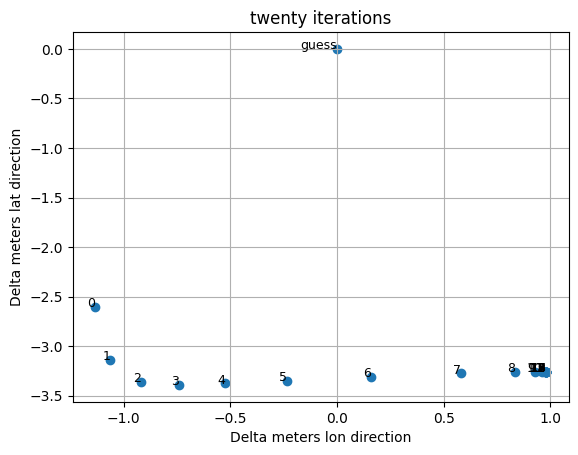

In [51]:
tuple_list = []
for i in range(len(fits)):
    tuple_list.append((f'{i}', fits[i]))

plot = ch.make_coord_plot(coords[1], tuple_list, 'twenty iterations')

In [19]:
joint_fits = []
joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = 'none'))
#joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = i))




 Starting fit of iteration 0



time for one delay pred: 0.01277470588684082
time taken pred 0.01288747787475586
time for one delay pred: 0.012232303619384766
time taken pred 0.012335777282714844
time for one delay pred: 0.01323699951171875
time taken pred 0.013332366943359375
time for one delay pred: 0.00853419303894043
time taken pred 0.008622407913208008
time for one delay pred: 0.014883995056152344
time taken pred 0.014976739883422852
time for one delay pred: 0.017132997512817383
time taken pred 0.017230987548828125
time for one delay pred: 0.011965513229370117
time taken pred 0.012055158615112305
time for one delay pred: 0.013042211532592773
time taken pred 0.013129711151123047
time for one delay pred: 0.008466005325317383
time taken pred 0.008551836013793945
time for one delay pred: 0.011890649795532227
time taken pred 0.011980295181274414
time for one delay pred: 0.009567499160766602
time taken pred 0.009652853012084961
time for one delay pred: 0.008454322814941406
time taken

In [27]:
joint_fits.append(ef.joint_irls(coords[1], ef.pred, pl, context, iterations = 1))




 Starting fit of iteration 0



time for one delay pred: 0.012241601943969727
time taken pred 0.012366533279418945
time for one delay pred: 0.012232303619384766
time taken pred 0.01235198974609375
time for one delay pred: 0.013498067855834961
time taken pred 0.013606548309326172
time for one delay pred: 0.008462905883789062
time taken pred 0.008553504943847656
time for one delay pred: 0.014240026473999023
time taken pred 0.01433253288269043
time for one delay pred: 0.01720452308654785
time taken pred 0.017299652099609375
time for one delay pred: 0.01196599006652832
time taken pred 0.012056827545166016
time for one delay pred: 0.013197183609008789
time taken pred 0.013286590576171875
time for one delay pred: 0.008547782897949219
time taken pred 0.008633613586425781
time for one delay pred: 0.0118560791015625
time taken pred 0.01194453239440918
time for one delay pred: 0.009679317474365234
time taken pred 0.009765625
time for one delay pred: 0.008414268493652344
time taken pred 0.0085

[ 79.41721848 -90.75872502 183.51076468]
[ 79.41723874 -90.75876639 181.15130772]


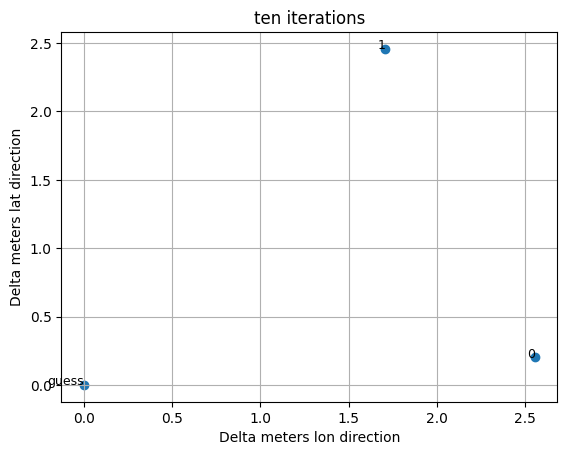

In [32]:
for i in range(len(joint_fits)):
    print(joint_fits[i][:3])

tuple_list = []
for i in range(len(joint_fits)):
    tuple_list.append((f'{i}', joint_fits[i]))

plot = ch.make_coord_plot(coords[1], tuple_list, 'ten iterations')

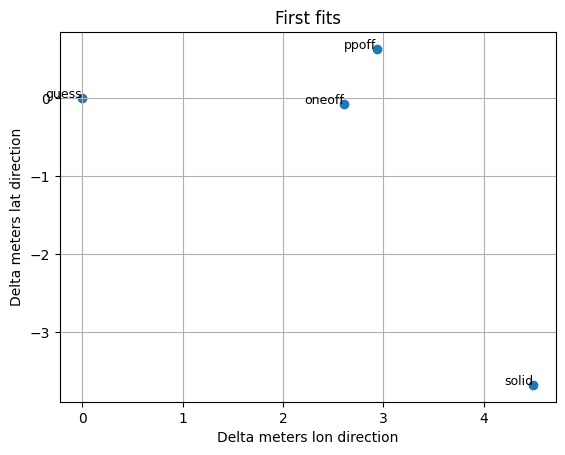

In [27]:
fig = ch.make_coord_plot(coords[1], tuple_list, 'First fits')

In [70]:
ds = ch.fit_ds_all(solid, ch.pred, pl, context)

time taken for one prediction 0.014196634292602539
time taken for one prediction 0.013453245162963867
time taken for one prediction 0.013193368911743164
time taken for one prediction 0.01315164566040039
time taken for one prediction 0.013200759887695312
time taken for one prediction 0.013089895248413086
time taken for one prediction 0.013300180435180664
time taken for one prediction 0.013020038604736328
time taken for one prediction 0.013151407241821289
time taken for one prediction 0.013346433639526367
time taken for one prediction 0.013834714889526367
time taken for one prediction 0.013999462127685547
time taken for one prediction 0.013990163803100586
time taken for one prediction 0.013844728469848633
time taken for one prediction 0.01389455795288086
time taken for one prediction 0.013894319534301758
time taken for one prediction 0.014011144638061523
time taken for one prediction 0.013907194137573242
time taken for one prediction 0.014025211334228516
time taken for one prediction 0.0

In [71]:
solid2 = ch.fit_given_offsets(coords[1], ch.pred, ds, pl, context)[0]
solid3 = ch.fit_given_offsets(solid, ch.pred, ds, pl, context)[0]

time taken for one prediction 0.013810396194458008
time taken for one prediction 0.014114856719970703
time taken for one prediction 0.0069425106048583984
time taken for one prediction 0.0069849491119384766
time taken for one prediction 0.009336709976196289
time taken for one prediction 0.010097980499267578
time taken for one prediction 0.01058650016784668
time taken for one prediction 0.009371757507324219
time taken for one prediction 0.011368751525878906
time taken for one prediction 0.009310007095336914
time taken for one prediction 0.011327028274536133
time taken for one prediction 0.012793779373168945
time taken for one prediction 0.01181793212890625
time taken for one prediction 0.011402606964111328
time taken for one prediction 0.017885208129882812
time taken for one prediction 0.011393070220947266
time taken for one prediction 0.01384592056274414
time taken for one prediction 0.01557302474975586
time taken for one prediction 0.01981329917907715
time taken for one prediction 0.01

In [72]:
tuple_list_2 = [('s1', solid), ('s2', solid2), ('s3', solid3)]

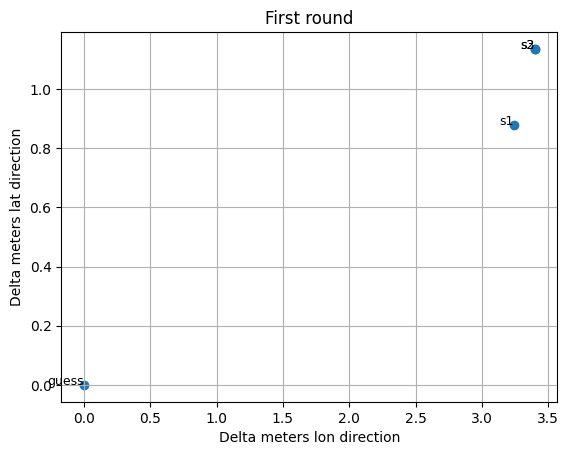

In [73]:
fig = ch.make_coord_plot(coords[1], tuple_list_2, 'First round')

In [74]:
cov = ch.fit_cov(solid, ch.pred, pl, context)

time taken for one prediction 0.013889789581298828
time taken for one prediction 0.01436305046081543
time taken for one prediction 0.006948709487915039
time taken for one prediction 0.007087230682373047
time taken for one prediction 0.009275197982788086
time taken for one prediction 0.010046243667602539
time taken for one prediction 0.010611772537231445
time taken for one prediction 0.00917506217956543
time taken for one prediction 0.011430740356445312
time taken for one prediction 0.009496450424194336
time taken for one prediction 0.011430025100708008
time taken for one prediction 0.012427568435668945
time taken for one prediction 0.011923074722290039
time taken for one prediction 0.011420249938964844
time taken for one prediction 0.01826190948486328
time taken for one prediction 0.011436223983764648
time taken for one prediction 0.01434636116027832
time taken for one prediction 0.015752792358398438
time taken for one prediction 0.020255565643310547
time taken for one prediction 0.016

time taken for one prediction 0.01214289665222168
time taken for one prediction 0.011557579040527344
time taken for one prediction 0.01813530921936035
time taken for one prediction 0.011497735977172852
time taken for one prediction 0.014157533645629883
time taken for one prediction 0.015729188919067383
time taken for one prediction 0.019953012466430664
time taken for one prediction 0.016260385513305664
time taken for one prediction 0.02193307876586914
time taken for one prediction 0.013781547546386719
time taken for one prediction 0.012906789779663086
time taken for one prediction 0.013957500457763672
time taken for one prediction 0.006826877593994141
time taken for one prediction 0.006976604461669922
time taken for one prediction 0.00910639762878418
time taken for one prediction 0.009930133819580078
time taken for one prediction 0.010532140731811523
time taken for one prediction 0.009136438369750977
time taken for one prediction 0.011415958404541016
time taken for one prediction 0.009

In [75]:
print(cov[0])
tuple_list_3 = [('s1', solid), ('ppoff', ppoff), ('cov', cov[0])]

[ 79.41720098 -90.75889116 183.90471545]


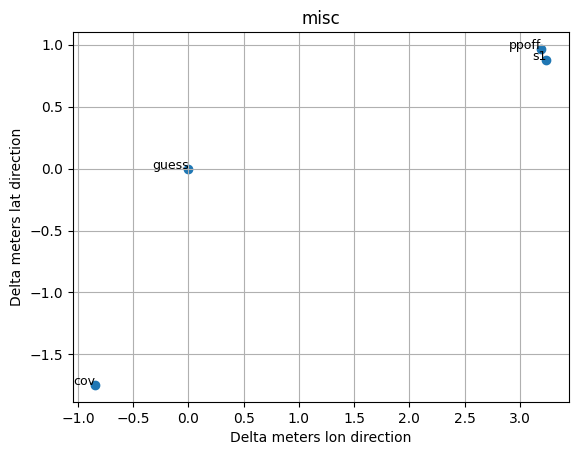

In [76]:
fig = ch.make_coord_plot(coords[1], tuple_list_3, 'misc')